## Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

base_dir = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

2026-03-28 15:17:17.974198: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774711037.998112    1049 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774711038.005717    1049 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774711038.024620    1049 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774711038.024644    1049 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774711038.024646    1049 computation_placer.cc:177] computation placer alr

## EDA

### Class Distribution

Total number of classes: 15
Total number of images: 20639
                                  Disease Class  Image Count
0         Tomato__Tomato_YellowLeaf__Curl_Virus         3209
1                         Tomato_Bacterial_spot         2127
2                            Tomato_Late_blight         1909
3                     Tomato_Septoria_leaf_spot         1771
4   Tomato_Spider_mites_Two_spotted_spider_mite         1676
5                                Tomato_healthy         1591
6                        Pepper__bell___healthy         1478
7                           Tomato__Target_Spot         1404
8                           Tomato_Early_blight         1000
9                         Potato___Early_blight         1000
10                         Potato___Late_blight         1000
11                Pepper__bell___Bacterial_spot          997
12                             Tomato_Leaf_Mold          952
13                  Tomato__Tomato_mosaic_virus          373
14                         

/tmp/ipykernel_1049/4253685492.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image Count', y='Disease Class', data=df_counts, palette='viridis')


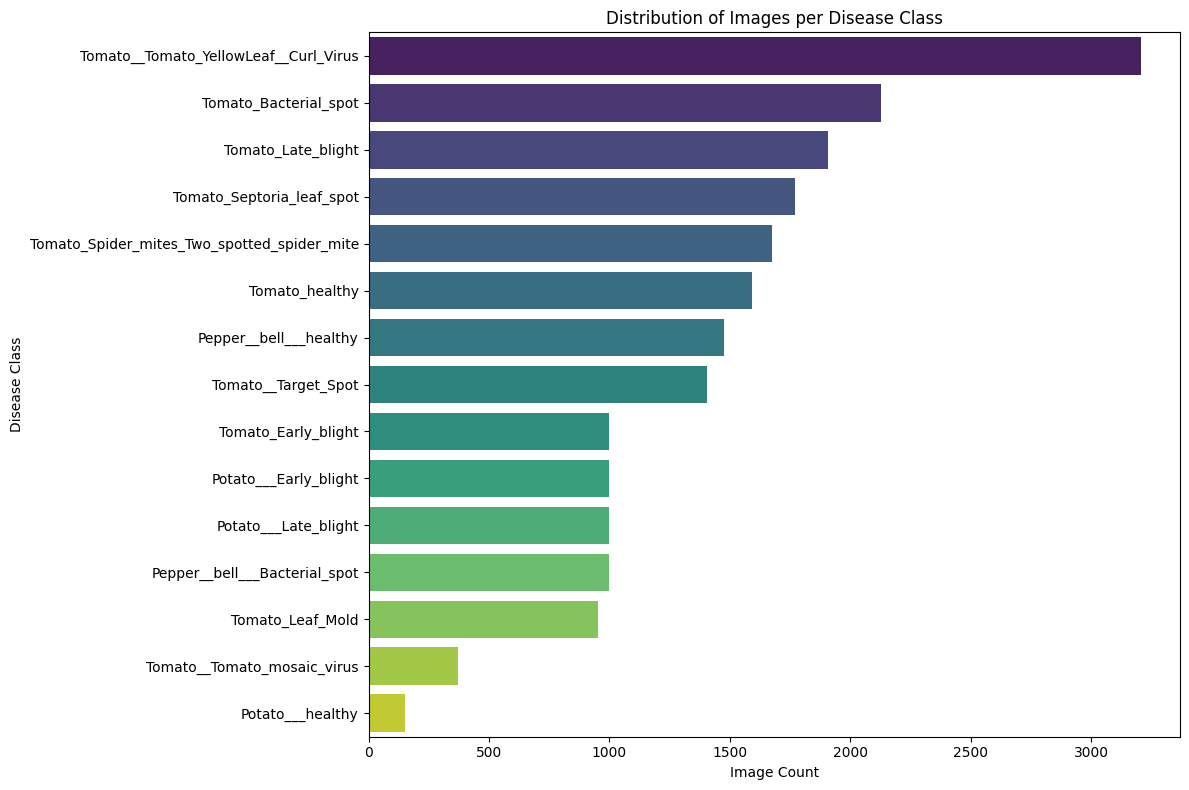

In [2]:
disease_counts = {}
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path): 
        disease_counts[folder] = len(os.listdir(folder_path))

df_counts = pd.DataFrame(list(disease_counts.items()), columns=['Disease Class', 'Image Count'])
df_counts = df_counts.sort_values(by='Image Count', ascending=False).reset_index(drop=True)

print("Total number of classes:", len(df_counts))
print("Total number of images:", df_counts['Image Count'].sum())
print(df_counts.to_string())

plt.figure(figsize=(12, 8))
sns.barplot(x='Image Count', y='Disease Class', data=df_counts, palette='viridis')
plt.title('Distribution of Images per Disease Class')
plt.tight_layout()
plt.show()

### Image Visualization

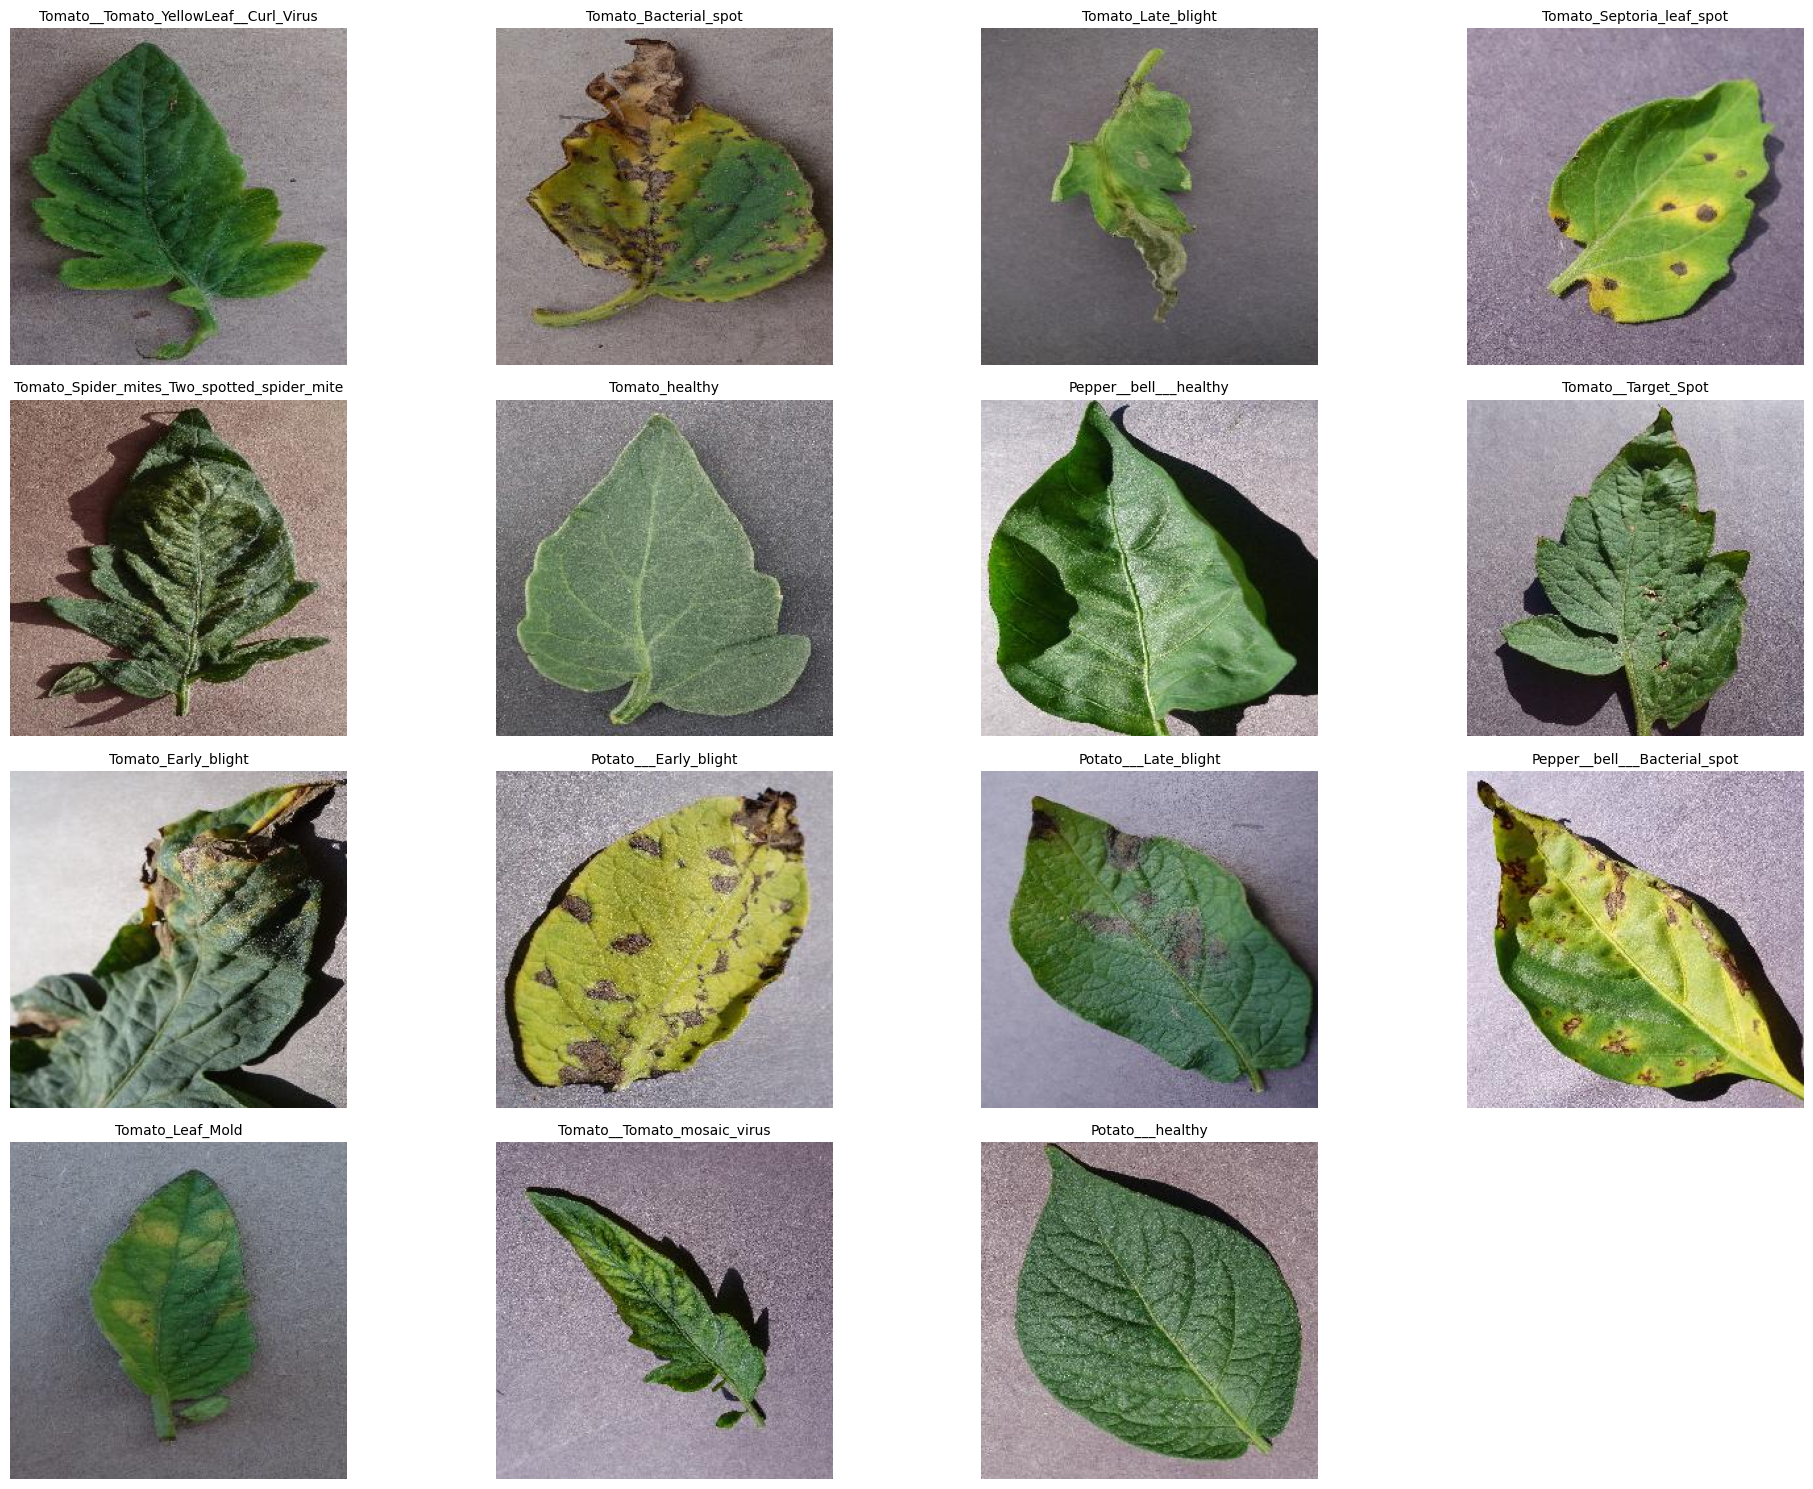

In [3]:
plt.figure(figsize=(20, 15))
for i, folder in enumerate(df_counts['Disease Class']):
    folder_path = os.path.join(base_dir, folder)
    images = os.listdir(folder_path)
    if not images: continue
    sample_img_name = random.choice(images)
    sample_img_path = os.path.join(folder_path, sample_img_name)
    
    img = mpimg.imread(sample_img_path)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(folder, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Loading

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


I0000 00:00:1774711053.912429    1049 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774711053.917544    1049 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


## Class Imbalance

In [5]:
y_train = np.concatenate([y for x, y in train_dataset], axis=0)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights_array))

## Model Architecture

In [6]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x) 
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Training

In [7]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_plant_model.keras", 
    save_best_only=True, 
    monitor='val_loss',
    mode='min'
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=3, 
    restore_best_weights=True,
    monitor='val_loss'
)

EPOCHS = 15

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/15


I0000 00:00:1774711073.977561    1122 cuda_dnn.cc:529] Loaded cuDNN version 91002


516/516 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.5574 - loss: 1.4625 - val_accuracy: 0.8205 - val_loss: 0.6041
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.8124 - loss: 0.5634 - val_accuracy: 0.8406 - val_loss: 0.5025
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.8328 - loss: 0.4776 - val_accuracy: 0.8522 - val_loss: 0.4607
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 67ms/step - accuracy: 0.8446 - loss: 0.4543 - val_accuracy: 0.8709 - val_loss: 0.4011
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.8501 - loss: 0.4289 - val_accuracy: 0.8738 - val_loss: 0.3853
Epoch 6/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.8611 - loss: 0.3945 - val_accuracy: 0.8723 - val_loss: 0.3880
Epoch 7/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 67ms/step - accuracy: 0.8597 - loss: 0.3878 - val_accuracy: 0.8735 - val_loss: 0.3750
Epoch 8/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.8647 - loss: 0.3896 - val_accurac

## Training History

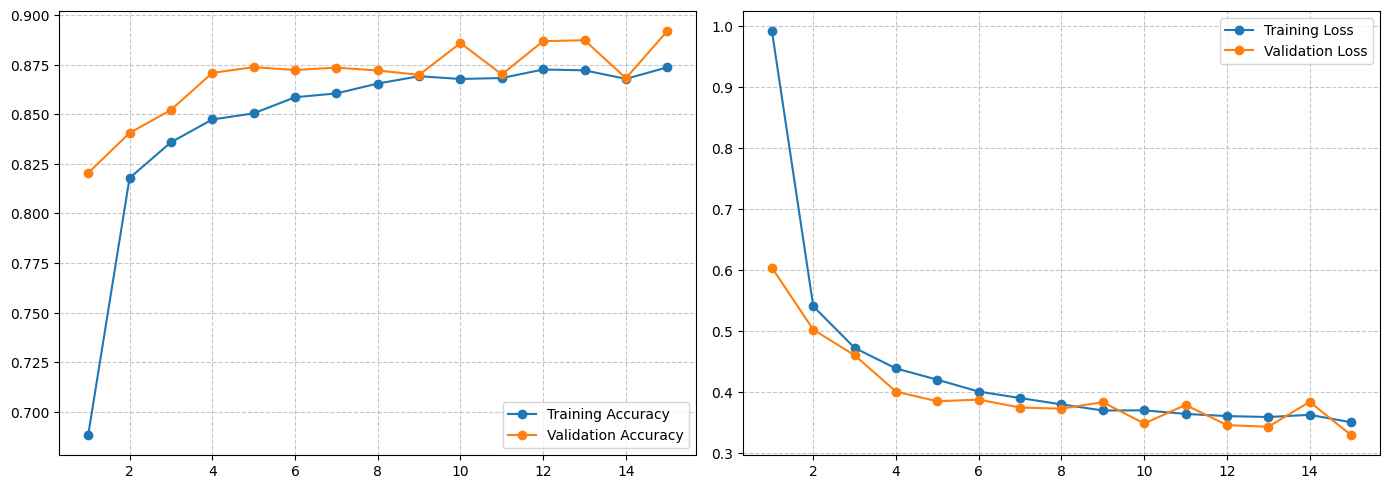

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Fine-Tuning

In [9]:
model.load_weights("best_plant_model.keras")

base_model.trainable = True
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

FINE_TUNE_EPOCHS = 10
total_epochs = EPOCHS + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=val_dataset,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 15/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 68s 107ms/step - accuracy: 0.6389 - loss: 1.7032 - val_accuracy: 0.8488 - val_loss: 0.4704
Epoch 16/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.8193 - loss: 0.5434 - val_accuracy: 0.8553 - val_loss: 0.4515
Epoch 17/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.8475 - loss: 0.4417 - val_accuracy: 0.8747 - val_loss: 0.3847
Epoch 18/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.8661 - loss: 0.3804 - val_accuracy: 0.8750 - val_loss: 0.3749
Epoch 19/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.8768 - loss: 0.3423 - val_accuracy: 0.8805 - val_loss: 0.3725
Epoch 20/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 54s 104ms/step - accuracy: 0.8959 - loss: 0.2780 - val_accuracy: 0.8788 - val_loss: 0.3637
Epoch 21/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 54s 104ms/step - accuracy: 0.9047 - loss: 0.2654 - val_accuracy: 0.8958 - val_loss: 0.3017
Epoch 22/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 54s 104ms/step - accuracy: 0.9090 -

## Final Evaluation

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.97      0.97       200
                     Pepper__bell___healthy       0.97      0.99      0.98       302
                      Potato___Early_blight       0.96      0.98      0.97       189
                       Potato___Late_blight       0.93      0.95      0.94       188
                           Potato___healthy       0.86      0.97      0.91        31
                      Tomato_Bacterial_spot       0.96      0.89      0.92       441
                        Tomato_Early_blight       0.88      0.70      0.78       191
                         Tomato_Late_blight       0.94      0.89      0.92       341
                           Tomato_Leaf_Mold       0.96      0.89      0.92       185
                  Tomato_Septoria_leaf_spot       0.88      0.90      0.89       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.93      0.81

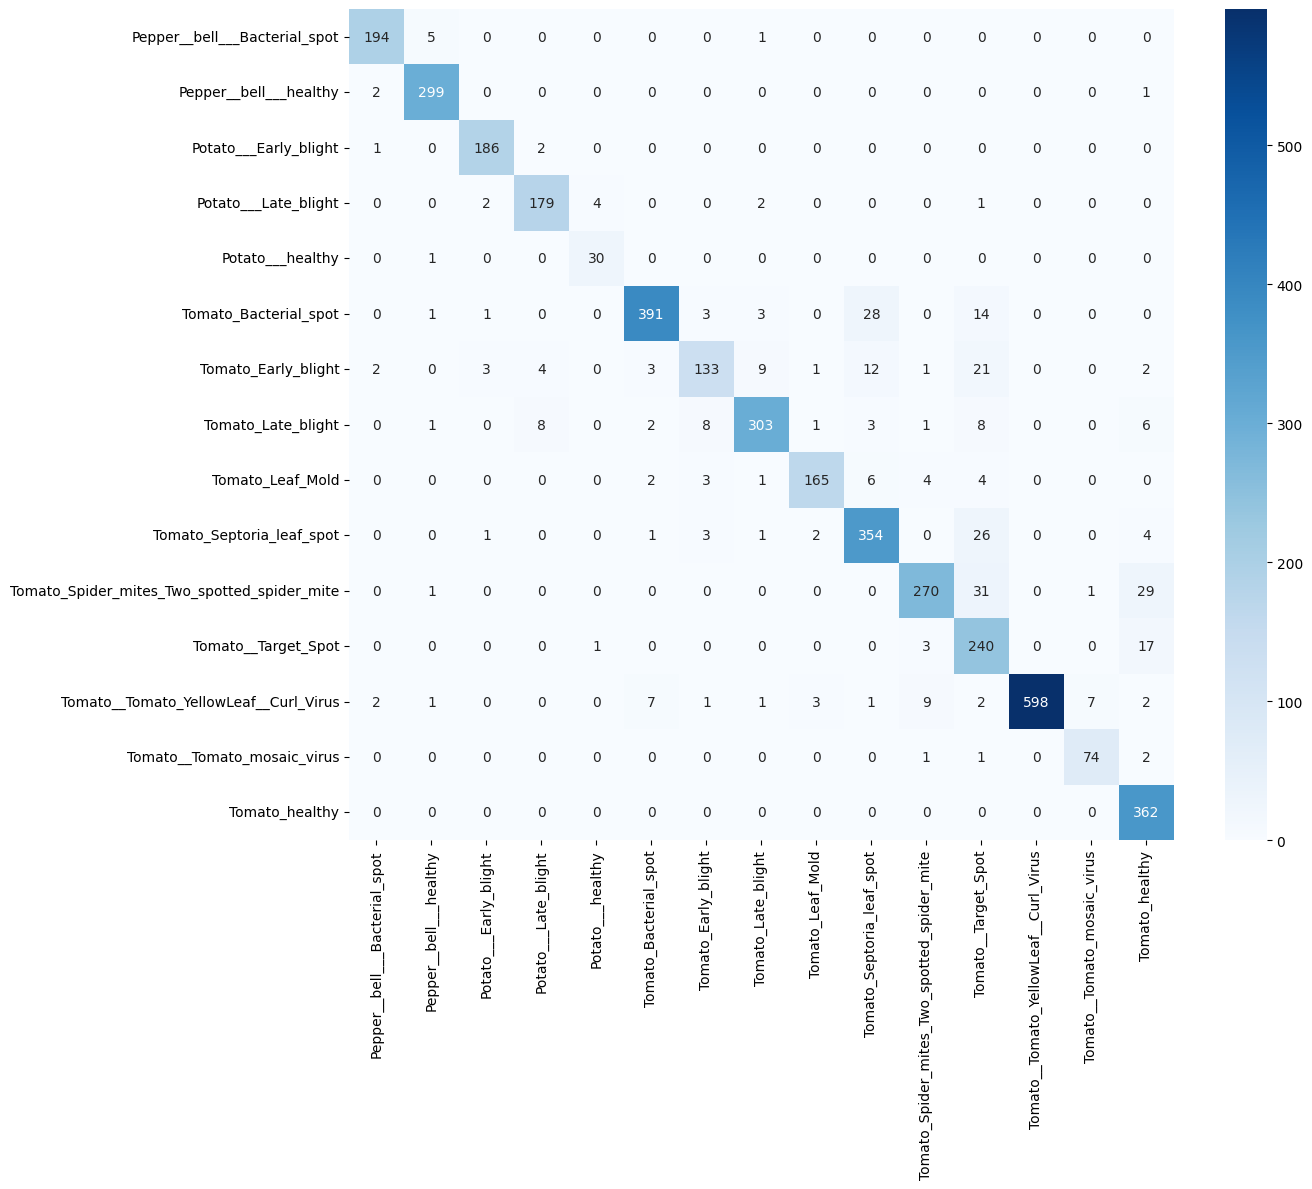

In [10]:
model.load_weights("best_plant_model.keras")

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()